## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as math
from matplotlib.backends.backend_pdf import PdfPages

## Airfoil Data ( NACA 0012 )

In [2]:
# NACA 0012 Given data (angle of attack in degrees, Cl values)
data = np.array([
    [-16.2500, -0.6742], [-16.0000, -0.9991], [-15.7500, -1.0281], [-15.5000, -1.0555], 
    [-15.2500, -1.0806], [-15.0000, -1.0994], [-14.7500, -1.1090], [-14.5000, -1.1130], 
    [-14.2500, -1.1162], [-14.0000, -1.1178], [-13.7500, -1.1192], [-13.5000, -1.1182], 
    [-13.2500, -1.1181], [-13.0000, -1.1180], [-12.7500, -1.1174], [-12.5000, -1.1162], 
    [-12.2500, -1.1150], [-12.0000, -1.1150], [-11.7500, -1.1047], [-11.5000, -1.0933], 
    [-11.2500, -1.0824], [-11.0000, -1.0715], [-10.7500, -1.0600], [-10.5000, -1.0485], 
    [-10.2500, -1.0371], [-10.0000, -1.0256], [-9.7500, -1.0121], [-9.5000, -0.9989], 
    [-9.2500, -0.9857], [-9.0000, -0.9722], [-8.7500, -0.9582], [-8.5000, -0.9438], 
    [-8.2500, -0.9289], [-8.0000, -0.9135], [-7.7500, -0.8988], [-7.5000, -0.8739], 
    [-7.2500, -0.8430], [-7.0000, -0.8110], [-6.7500, -0.7783], [-6.5000, -0.7480], 
    [-6.2500, -0.7188], [-6.0000, -0.6868], [-5.7500, -0.6530], [-5.5000, -0.6184], 
    [-5.2500, -0.5914], [-5.0000, -0.5603], [-4.7500, -0.5272], [-4.5000, -0.4932], 
    [-4.2500, -0.4586], [-4.0000, -0.4335], [-3.7500, -0.4036], [-3.5000, -0.3741], 
    [-3.2500, -0.3462], [-3.0000, -0.3249], [-2.7500, -0.3003], [-2.5000, -0.2716], 
    [-2.2500, -0.2413], [-2.0000, -0.2188], [-1.7500, -0.1898], [-1.5000, -0.1595], 
    [-1.2500, -0.1352], [-1.0000, -0.1072], [-0.7500, -0.0794], [-0.5000, -0.0544], 
    [-0.2500, -0.0258], [0, 0], [0.2500, 0.0259], [0.7500, 0.0794], 
    [1.0000, 0.1072], [1.2500, 0.1352], [1.5000, 0.1595], [1.7500, 0.1898], 
    [2.0000, 0.2188], [2.2500, 0.2413], [2.5000, 0.2716], [2.7500, 0.3002], 
    [3.0000, 0.3249], [3.2500, 0.3462], [3.5000, 0.3741], [3.7500, 0.4037], 
    [4.0000, 0.4334], [4.2500, 0.4586], [4.5000, 0.4933], [4.7500, 0.5272], 
    [5.0000, 0.5603], [5.2500, 0.5914], [5.5000, 0.6184], [5.7500, 0.6530], 
    [6.0000, 0.6868], [6.2500, 0.7188], [6.5000, 0.7481], [6.7500, 0.7783], 
    [7.0000, 0.8111], [7.2500, 0.8431], [7.5000, 0.8741], [7.7500, 0.8987], 
    [8.0000, 0.9133], [8.2500, 0.9288], [8.5000, 0.9436], [8.7500, 0.9581], 
    [9.0000, 0.9721], [9.2500, 0.9856], [9.5000, 0.9987], [9.7500, 1.0120], 
    [10.0000, 1.0255], [10.2500, 1.0370], [10.5000, 1.0485], [10.7500, 1.0600], 
    [11.0000, 1.0715], [11.2500, 1.0825], [11.5000, 1.0935], [11.7500, 1.1050], 
    [12.0000, 1.1154], [12.2500, 1.1154], [12.5000, 1.1168], [12.7500, 1.1180], 
    [13.0000, 1.1187], [13.2500, 1.1189], [13.5000, 1.1192], [13.7500, 1.1204], 
    [14.0000, 1.1190], [14.2500, 1.1177], [14.5000, 1.1151], [14.7500, 1.1104], 
    [15.0000, 1.1008], [15.2500, 1.0814], [15.5000, 1.0554], [15.7500, 1.0285], 
    [16.0000, 0.9995]
])

## Lift - Curve Slope Calculation

In [3]:
alpha = data[:, 0]
Cl = data[:, 1]

mask = (alpha >= -12) & (alpha <= 12)

alpha_selected = alpha[mask]
Cl_selected = Cl[mask]

gradient_selected = np.gradient(Cl_selected, alpha_selected)

average_gradient = np.mean(gradient_selected)

Cl_alpha = (average_gradient * 180) / np.pi

print("Cl_alpha =", Cl_alpha)

Cl_alpha = 5.285615237553389


## Airfoil Lookup Function

In [4]:
def extrapolate_lookup(array, search_value):

    array = array[array[:, 0].argsort()]

    for i in range(len(array) - 1):

        x1, y1 = array[i]
        x2, y2 = array[i + 1]

        if x1 <= search_value <= x2:

            slope = (y2 - y1) / (x2 - x1)

            return y1 + slope * (search_value - x1)

    return None

## Gaussian Quadrature Setup

In [5]:
nodes = np.array([
-0.932469514, -0.661209386, -0.238619186,
 0.238619186,  0.661209386,  0.932469514
])

weights = np.array([
0.171324492, 0.360761573, 0.467913935,
0.467913935, 0.360761573, 0.171324492
])

## BEMT Solver Function

In [6]:
def compute_Ct_Cp(theta_root, twist, R, R_cut, c, Nb):

    Cdo = 0.01
    kappa = 1.15
    n = 20

    Area = np.pi * (R**2)
    BA = c * (R - R_cut)

    sgm = Nb*c*(R-R_cut)/(np.pi*R*R)

    dy = (1-R_cut)/n
    CPo = (sgm * Cdo) / 8

    Ct_integral = 0
    CPi_integral = 0

    for i in range(n):

        a = R_cut + dy*i
        b = R_cut + dy*(i+1)

        for j in range(6):

            r = 0.5 * (nodes[j] + 1) * (b - a) + a

            theta = theta_root - (twist * r)
            theta = ( theta * np.pi ) / 180

            lambda_r = ((sgm*Cl_alpha)/16)*(((1+((32*theta*r)/(sgm*Cl_alpha)))**0.5)-1)

            search_val = ( theta - ( lambda_r / r ) ) * (180/np.pi)

            Cl_lookup = extrapolate_lookup(data, search_val)

            Ct_integrand = 0.5 * sgm * Cl_lookup * (r**2)

            Ct_integral += weights[j] * Ct_integrand * ((b - a) / 2)

            CPi_integrand = Ct_integrand * lambda_r

            CPi_integral += weights[j] * CPi_integrand * ((b - a) / 2)

    CT = Ct_integral
    CP = (kappa * CPi_integral) + CPo

    return CT, CP

## Component Weight Model

In [7]:

def computeGTOW(R, sgm, Nb, Cell_capacity, cells, I_max, Kv, rotor_max_power):

    # Weights of all components computed in grams
    
    mR = (0.0195) * ((R*100)**(2.0859)) * ((sgm)**(-0.2038)) * ((Nb)**(0.5344)) # Rotor weight (g)

    lBL = (4.8910) * ((I_max)**(0.1751)) * ((rotor_max_power)**(0.2476))        # Motor casing length (mm)
    dBL = (41.45) * ((Kv)**(-0.1919)) * ((rotor_max_power)**(0.1935))           # Motor diameter (mm)
    log_lBL = math.log10(lBL)
    log_dBL = math.log10(dBL)

    # Brushless DC motor weight (g)
    mBL = (0.0109) * ((Kv)**(0.5122)) * ((rotor_max_power)**(-0.1902)) * ((log_lBL)**(2.5582)) * ((log_dBL)**(12.8502))

    mESCBL = (0.8013) * ((I_max)**(0.9727))                                     # ESC for BLDC weight (g)

    mBat = (0.0418) * ((Cell_capacity)**(0.9327)) * ((cells)**(1.0725))         # Battery weight (g)

    mAF = (1.3119) * ((R*100)**(1.2767)) * ((mBat)**(0.4587))                   # Airframe weight (g)

    newGTOW = (4 * (mR + mBL + mESCBL)) + mBat + mAF + payload                  # New Gross Takeoff Weight (g)

    return mR, mBL, mESCBL, mBat, mAF, newGTOW

## Physical Constants

In [8]:
# Constants
rho = 1.225      # Density of air(kg/m^3)   
Cdo = 0.01       # Profile drag coefficient 
kappa = 1.15     # Induced power factor
nm = 0.8         # Motor Efficiency
n = 20           # Number of radial segments

## Rotor geometry inputs

In [9]:

# Rotor data
theta_root = 22   # Blade pitch at root (in degrees)
twist = 17        # Blade twist angle (in degrees per blade radius)
R = 0.0979           # Blade Radius (m)
R_cut = 0         # Non-dimensional root cutout (m)
c = 0.0163          # Blade chord (m)
Nb = 2            # Number of blades 

# Vary R from ((0.9 * 9.81) / (4 * np.pi * 40))**0.5 to ((0.9 * 9.81) / (4 * np.pi * 90))**0.5

## Mission Inputs

In [10]:

# Mission and battery data
payload = 300         # payload mass (g)
endurance = 20        # in minutes
cells = 4             # connected in series
volt_per_cell = 3.7   # in volts (V)

## Initial Calculations

In [11]:
# Calculated data
# Motor and Battery data
gtow = ((payload * 3) / 1000) * 9.81                # initial estimate of gtow
V_total = cells * volt_per_cell                     # Total battery voltage (V)

# Rotor data
Area = np.pi * (R**2)                # Disk Area (m^2)
BA = c * (R - R_cut)                 # Blade Area (m^2)
sgm = (Nb * BA) / Area               # Rotor Solidity (for rectangular planform) 


## Run BEMT

In [12]:
# function signature for reference
# computeCt(theta_root, twist, R, R_cut, c, Nb)
rotor_Ct, rotor_Cp = compute_Ct_Cp(theta_root, twist, R, R_cut, c, Nb)
print(f'Rotor Ct: {rotor_Ct:.8f}')
print(f'Rotor Cp: {rotor_Cp:.8f}')

Rotor Ct: 0.00832763
Rotor Cp: 0.00070640


## Iterative GTOW Convergence

In [13]:
max_iterations = 20
counter = 0
diff = 10
old_gtow = gtow * 1000 / 9.81

## Iteration Loop

In [14]:
while counter < max_iterations and diff > 5:

    # Compute derived variables
    hover_thrust = (old_gtow / 1000) * 9.81     # new hover thrust value (N)
    max_thrust = hover_thrust * 2               # max thrust value
    rotor_hover_thrust = hover_thrust / 4       # hover thrust divided among 4 rotors for quadrotor
    rotor_max_thrust = max_thrust / 4           # max thrust divided among 4 rotors for quadrotor
    disk_loading = gtow / (Area * 4)            # disk loading per rotor

    # Thrust = Ct_integral * rho * Area * ( (Omega * R)**2 )                    # Total Thrust
    Omega_hover = (((rotor_hover_thrust / (rotor_Ct * rho * Area))**0.5) / R)   # in rad/sec
    Omega_hover_RPM = Omega_hover * (60/(2*np.pi))                              # in RPM
    Omega_max = (((rotor_max_thrust / (rotor_Ct * rho * Area))**0.5) / R)       # in rad/sec
    Omega_max_RPM = Omega_max * (60/(2*np.pi))                                  # in RPM
    
    rotor_hover_power = rotor_Cp * rho * Area * ((Omega_hover * R)**3) / nm   # Hover Power per rotor
    hover_Power = rotor_hover_power * 4                                 # Total hover power requirement
    rotor_max_power = rotor_Cp * rho * Area * ((Omega_max * R)**3) / nm       # Max Power per rotor
    max_Power = rotor_max_power * 4                                     # Total max power requirement
    
    Energy = hover_Power * endurance * 60 * 1.25              # in joules (scale up energy requirement to keep 20% reserve)
    Cell_capacity = (Energy / V_total) * (1000 / 3600)        # in mAh
    
    I_max = rotor_max_power / V_total                         # max current drawn by each motor (A)
    Kv = Omega_max_RPM / V_total                              # Kv of each motor (RPM/V)

    print('')
    print('')
    print(f'**************** Iteration {counter} ****************')
    print('')
    print(f'{"Omega for hover (RPM):".ljust(35)} {Omega_hover_RPM:.2f}')
    print(f'{"Omega maximum (RPM):".ljust(35)} {Omega_max_RPM:.2f}')
    print(f'{"Hover thrust per rotor (N):".ljust(35)} {rotor_hover_thrust:.2f}')
    print(f'{"Max thrust per rotor (N):".ljust(35)} {rotor_max_thrust:.2f}')
    print(f'{"Hover power per rotor (W):".ljust(35)} {rotor_hover_power:.2f}')
    print(f'{"Max power per rotor (W):".ljust(35)} {rotor_max_power:.2f}')
    print('')
    print(f'{"Max Current drawn per motor (A):".ljust(35)} {I_max:.2f}')
    print(f'{"Kv of each motor (RPM/V):".ljust(35)} {Kv:.2f}')
    print(f'{"Mission energy (J) or (Ws):".ljust(35)} {Energy:.2f}')
    print(f'{"Battery cell capacity (mAh):".ljust(35)} {Cell_capacity:.2f}')


    mR, mBL, mESCBL, mBat, mAF, newGTOW = computeGTOW(R, sgm, Nb, Cell_capacity, cells, I_max, Kv, rotor_max_power)

    print('')

    print(f'GTOW = {newGTOW:.2f}, Rotor = {mR:.2f}, Motor  = {mBL:.2f}, ESC = {mESCBL:.2f}, Battery = {mBat:.2f}, Airframe = {mAF:.2f}')
    
    diff = abs(old_gtow - newGTOW)
    
    old_gtow = newGTOW

    counter = counter + 1

print(' ')
print(f'{"Rotor Radius (m):".ljust(35)} {R:.5f}')
print(f'{"Rotor Chord (m):".ljust(35)} {c:.5f}')
print(f'{"Rotor Thrust Coefficient (Ct):".ljust(35)} {rotor_Ct:.8f}')
print(f'{"Rotor Power Coefficient (Cp):".ljust(35)} {rotor_Cp:.8f}')



**************** Iteration 0 ****************

Omega for hover (RPM):              8268.53
Omega maximum (RPM):                11693.46
Hover thrust per rotor (N):         2.21
Max thrust per rotor (N):           4.41
Hover power per rotor (W):          19.84
Max power per rotor (W):            56.11

Max Current drawn per motor (A):    3.79
Kv of each motor (RPM/V):           790.10
Mission energy (J) or (Ws):         119036.38
Battery cell capacity (mAh):        2234.17

GTOW = 958.05, Rotor = 5.20, Motor  = 19.53, ESC = 2.93, Battery = 245.81, Airframe = 301.58


**************** Iteration 1 ****************

Omega for hover (RPM):              8531.02
Omega maximum (RPM):                12064.68
Hover thrust per rotor (N):         2.35
Max thrust per rotor (N):           4.70
Hover power per rotor (W):          21.79
Max power per rotor (W):            61.63

Max Current drawn per motor (A):    4.16
Kv of each motor (RPM/V):           815.18
Mission energy (J) or (Ws):         13

In [15]:
# ------------------ PARAMETER SWEEP (CORRECTED) ------------------

R_range = np.linspace(0.08, 0.105, 8)   # realistic radius range (8–10.5 cm)
AR_range = np.linspace(4, 6, 5)         # constrained aspect ratio
Nb_range = [2, 3]
cells_range = [3, 4]

best_gtow = 1e9
best_config = None

for R_sweep in R_range:
    for AR in AR_range:
        for Nb in Nb_range:
            for cells in cells_range:

                R = R_sweep
                c = R / AR   # chord from aspect ratio

                # Geometry
                Area = np.pi * (R**2)
                BA = c * (R - R_cut)
                sgm = (Nb * BA) / Area

                # Skip unrealistic chord (safety check)
                if c < 0.012 or c > 0.03:
                    continue

                # Compute Ct, Cp
                rotor_Ct, rotor_Cp = compute_Ct_Cp(theta_root, twist, R, R_cut, c, Nb)

                # Initial GTOW guess
                gtow = ((payload * 3) / 1000) * 9.81
                old_gtow = gtow * 1000 / 9.81

                counter = 0
                diff = 10

                while counter < 20 and diff > 5:

                    hover_thrust = (old_gtow / 1000) * 9.81
                    rotor_hover_thrust = hover_thrust / 4

                    Omega_hover = (((rotor_hover_thrust / (rotor_Ct * rho * Area))**0.5) / R)
                    Omega_max = Omega_hover * np.sqrt(2)

                    rotor_hover_power = rotor_Cp * rho * Area * ((Omega_hover * R)**3) / nm
                    rotor_max_power = rotor_Cp * rho * Area * ((Omega_max * R)**3) / nm

                    hover_Power = rotor_hover_power * 4

                    Energy = hover_Power * endurance * 60 * 1.25
                    V_total = cells * volt_per_cell
                    Cell_capacity = (Energy / V_total) * (1000 / 3600)

                    I_max = rotor_max_power / V_total
                    Omega_max_RPM = Omega_max * (60/(2*np.pi))
                    Kv = Omega_max_RPM / V_total

                    mR, mBL, mESCBL, mBat, mAF, newGTOW = computeGTOW(
                        R, sgm, Nb, Cell_capacity, cells, I_max, Kv, rotor_max_power
                    )

                    diff = abs(old_gtow - newGTOW)
                    old_gtow = newGTOW
                    counter += 1

                if newGTOW < best_gtow:
                    best_gtow = newGTOW
                    best_config = (R, AR, c, Nb, cells)

# ------------------ OUTPUT ------------------

print("\nBest Realistic Design Found:")
print(f"GTOW: {best_gtow:.2f} g")
print(f"R: {best_config[0]:.4f} m")
print(f"Aspect Ratio: {best_config[1]:.2f}")
print(f"Chord (m): {best_config[2]:.4f}")
print(f"Blades: {best_config[3]}")
print(f"Cells: {best_config[4]}")
# Aspect ratio = 6


Best Realistic Design Found:
GTOW: 1048.03 g
R: 0.0979 m
Aspect Ratio: 6.00
Chord (m): 0.0163
Blades: 2
Cells: 3


## Cord for parametric study

In [16]:
R_range = np.linspace(0.095, 0.115, 6)

c_range = np.linspace(0.014, 0.018, 6)

In [17]:
study_results = []

theta_root = 22
Nb = 2

for R in R_range:
    for c in c_range:

        # Geometry
        Area = np.pi * R**2
        BA = c * (R - R_cut)
        sgm = (Nb * BA) / Area

        # Aspect ratio
        AR = R / c

        # Skip unrealistic AR
        if AR < 4 or AR > 8:
            continue

        # Compute Ct, Cp
        rotor_Ct, rotor_Cp = compute_Ct_Cp(theta_root, twist, R, R_cut, c, Nb)

        # Initial GTOW
        old_gtow = payload * 3.0
        diff = 10
        counter = 0

        while counter < 20 and diff > 5:

            hover_thrust = (old_gtow / 1000) * 9.81
            rotor_hover_thrust = hover_thrust / 4

            Omega = (((rotor_hover_thrust / (rotor_Ct * rho * Area))**0.5) / R)

            rotor_power = rotor_Cp * rho * Area * ((Omega * R)**3) / nm
            total_power = rotor_power * 4

            # Battery
            V_total = 3 * volt_per_cell
            Energy = total_power * endurance * 60 * 1.25
            Cell_capacity = (Energy / V_total) * (1000 / 3600)

            I_max = rotor_power / V_total
            Omega_RPM = Omega * (60/(2*np.pi))
            Kv = Omega_RPM / V_total

            mR, mBL, mESCBL, mBat, mAF, newGTOW = computeGTOW(
                R, sgm, Nb, Cell_capacity, 3, I_max, Kv, rotor_power
            )

            diff = abs(old_gtow - newGTOW)
            old_gtow = newGTOW
            counter += 1

        # Disk loading
        DL = (newGTOW / 1000 * 9.81) / (4 * Area)

        study_results.append([R, c, AR, DL, newGTOW])

In [36]:
print("\nR (m)   c (m)   AR    DL(N/m²)   GTOW(g)")
for row in study_results:
    print(f"{row[0]:.4f}  {row[1]:.4f}  {row[2]:.2f}  {row[3]:.2f}  {row[4]:.2f}")


R (m)   c (m)   AR    DL(N/m²)   GTOW(g)
0.0950  0.0140  6.79  73.68  851.80
0.0950  0.0148  6.42  73.78  852.95
0.0950  0.0156  6.09  73.88  854.16
0.0950  0.0164  5.79  74.00  855.45
0.0950  0.0172  5.52  74.11  856.74
0.0950  0.0180  5.28  74.22  858.09
0.0990  0.0140  7.07  68.33  857.86
0.0990  0.0148  6.69  68.40  858.73
0.0990  0.0156  6.35  68.48  859.77
0.0990  0.0164  6.04  68.57  860.88
0.0990  0.0172  5.76  68.66  862.06
0.0990  0.0180  5.50  68.76  863.23
0.1030  0.0140  7.36  63.70  865.69
0.1030  0.0148  6.96  63.74  866.28
0.1030  0.0156  6.60  63.81  867.12
0.1030  0.0164  6.28  63.88  868.06
0.1030  0.0172  5.99  63.95  869.08
0.1030  0.0180  5.72  64.03  870.17
0.1070  0.0140  7.64  59.67  875.13
0.1070  0.0148  7.23  59.69  875.42
0.1070  0.0156  6.86  59.73  875.98
0.1070  0.0164  6.52  59.78  876.79
0.1070  0.0172  6.22  59.84  877.65
0.1070  0.0180  5.94  59.91  878.59
0.1110  0.0140  7.93  56.14  886.06
0.1110  0.0148  7.50  56.13  885.97
0.1110  0.0156  7.12  

## Convergence GTOW

In [18]:
def convergeGTOW(theta_root,disk_loading,aspect_ratio,Nb,cells):

    gtow = ((payload*3)/1000)*9.81
    V_total = cells*volt_per_cell

    R = (gtow/(4*np.pi*disk_loading))**0.5

    c = (R-R_cut)/aspect_ratio

    Area = np.pi*(R**2)

    BA = c*(R-R_cut)

    sgm = (Nb*BA)/Area

    rotor_Ct,rotor_Cp = compute_Ct_Cp(theta_root,twist,R,R_cut,c,Nb)

    max_iterations = 20
    diff = 10
    counter = 0

    old_gtow = gtow*1000/9.81

    while counter<max_iterations and diff>5:

        hover_thrust = (old_gtow/1000)*9.81
        max_thrust = hover_thrust*2

        rotor_hover_thrust = hover_thrust/4
        rotor_max_thrust = max_thrust/4

        Omega_hover = (((rotor_hover_thrust/(rotor_Ct*rho*Area))**0.5)/R)
        Omega_hover_RPM = Omega_hover*(60/(2*np.pi))

        Omega_max = (((rotor_max_thrust/(rotor_Ct*rho*Area))**0.5)/R)
        Omega_max_RPM = Omega_max*(60/(2*np.pi))

        rotor_hover_power = rotor_Cp*rho*Area*((Omega_hover*R)**3)/nm

        hover_power = rotor_hover_power*4

        rotor_max_power = rotor_Cp*rho*Area*((Omega_max*R)**3)/nm

        Energy = hover_power*endurance*60*1.25

        Cell_capacity = (Energy/V_total)*(1000/3600)

        I_max = rotor_max_power/V_total
        Kv = Omega_max_RPM/V_total

        mR,mBL,mESCBL,mBat,mAF,newGTOW = computeGTOW(R,sgm,Nb,Cell_capacity,cells,I_max,Kv,rotor_max_power)

        diff = abs(old_gtow-newGTOW)

        old_gtow = newGTOW

        counter +=1

    return newGTOW

## Base values

In [19]:
theta_root_base = 27.78
disk_loading_base = 84.44
aspect_ratio_base = 4
Nb_base = 2
cells_base = 3

## Parameter ranges

In [20]:
theta_root_range = np.linspace(20,30,50)
disk_loading_range = np.linspace(40,90,100)
aspect_ratio_range = np.linspace(3,13,50)

Nb_range = np.array([2,3])

cells_range = np.arange(3,7)

## Sensitivity plot function

In [21]:
def plot_sensitivity(parameter_values,parameter_name):

    gtow_values = []

    for value in parameter_values:

        theta_root = theta_root_base
        disk_loading = disk_loading_base
        aspect_ratio = aspect_ratio_base
        Nb = Nb_base
        cells = cells_base

        if parameter_name=="theta_root":
            theta_root=value
        elif parameter_name=="disk_loading":
            disk_loading=value
        elif parameter_name=="aspect_ratio":
            aspect_ratio=value
        elif parameter_name=="Nb":
            Nb=value
        elif parameter_name=="cells":
            cells=value

        gtow = convergeGTOW(theta_root,disk_loading,aspect_ratio,Nb,cells)

        gtow_values.append(gtow)

    gtow_values=np.array(gtow_values)

    min_index=np.argmin(gtow_values)

    optimal_param=parameter_values[min_index]
    optimal_gtow=gtow_values[min_index]

    print(f"Optimal {parameter_name}: {optimal_param}")
    print(f"Minimum GTOW: {optimal_gtow:.2f} g")

    plt.figure(figsize=(8,5))
    plt.plot(parameter_values,gtow_values,marker='o', color='red')
    plt.scatter(optimal_param,optimal_gtow,color='black')
    plt.xlabel(parameter_name)
    plt.ylabel("GTOW (g)")
    plt.title(f"GTOW Sensitivity to {parameter_name}")
    plt.grid(True)
    plt.show()

Optimal theta_root: 27.95918367346939
Minimum GTOW: 897.66 g


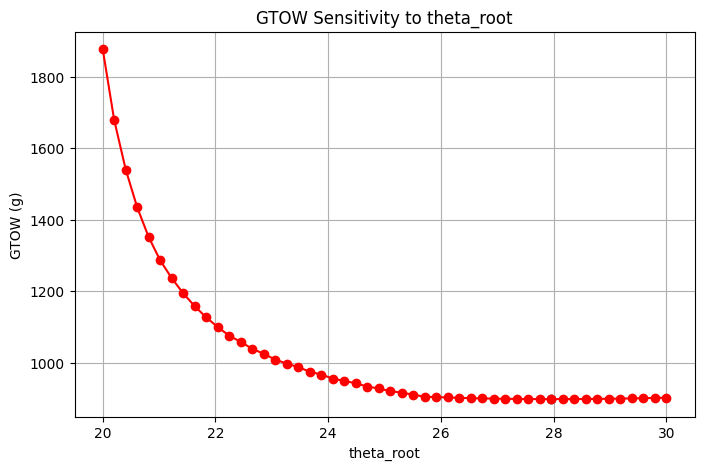

Optimal disk_loading: 84.44444444444446
Minimum GTOW: 897.70 g


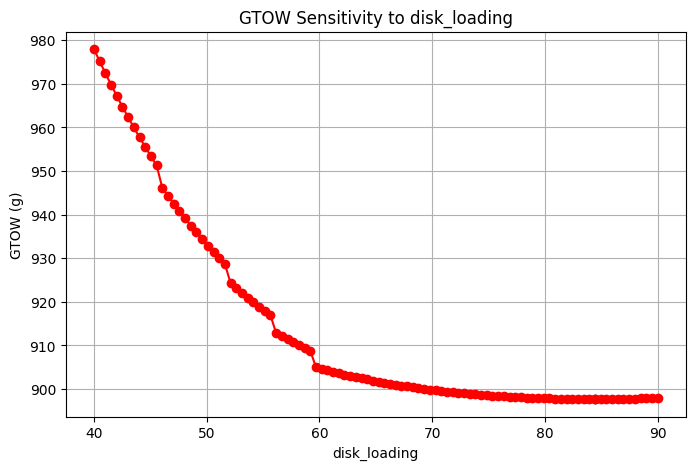

Optimal aspect_ratio: 3.204081632653061
Minimum GTOW: 896.46 g


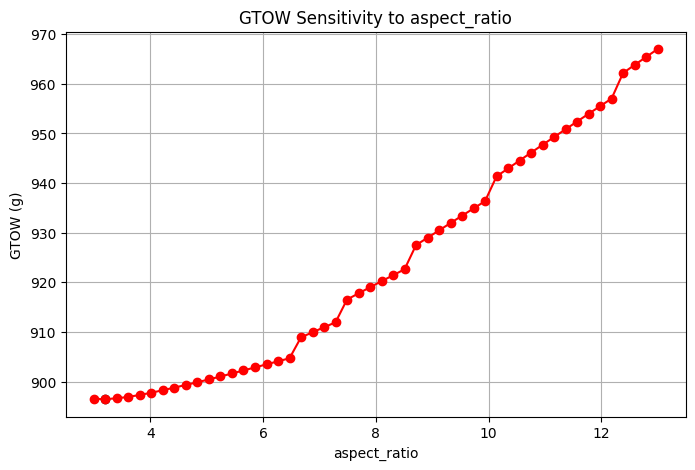

Optimal Nb: 2
Minimum GTOW: 897.70 g


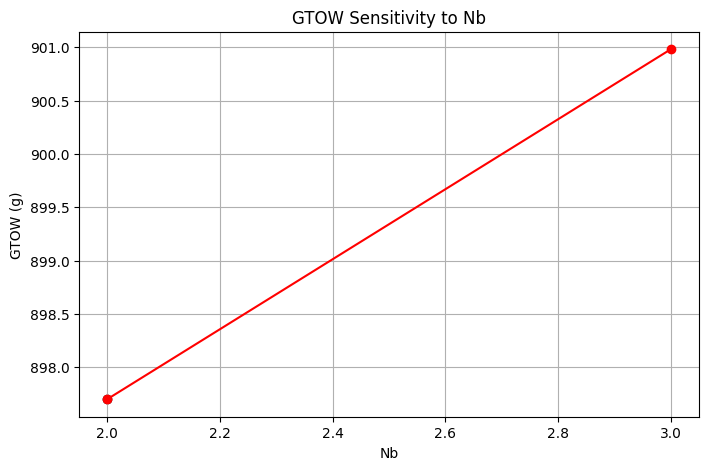

Optimal cells: 3
Minimum GTOW: 897.70 g


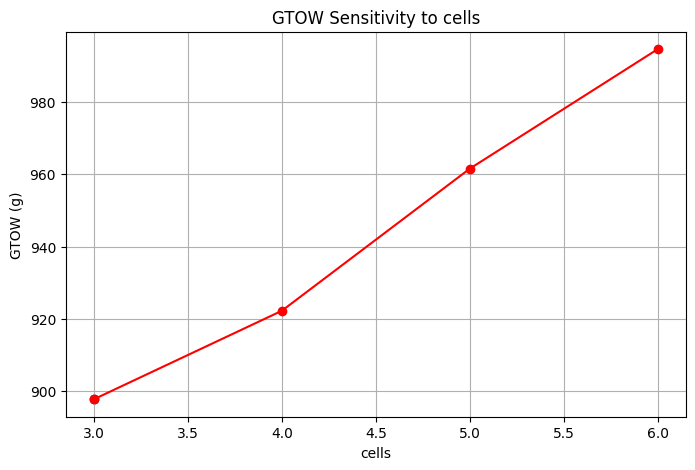

In [22]:
plot_sensitivity(theta_root_range,"theta_root")

plot_sensitivity(disk_loading_range,"disk_loading")

plot_sensitivity(aspect_ratio_range,"aspect_ratio")

plot_sensitivity(Nb_range,"Nb")

plot_sensitivity(cells_range,"cells")

In [23]:
theta_root_range = np.linspace(20,30,10)
disk_loading_range = np.linspace(40,90,10)
aspect_ratio_range = np.linspace(4,12,10)
Nb_range = [2,3]
cells_range = [3,4]

best_gtow = 1e9
best_config = None

for theta in theta_root_range:
    for dl in disk_loading_range:
        for ar in aspect_ratio_range:
            for nb in Nb_range:
                for cell in cells_range:

                    gtow = convergeGTOW(theta, dl, ar, nb, cell)

                    if gtow < best_gtow:
                        best_gtow = gtow
                        best_config = (theta, dl, ar, nb, cell)

print("\nBest Design Found")
print("GTOW:", best_gtow, "g")
print("theta_root:", best_config[0])
print("disk_loading:", best_config[1])
print("aspect_ratio:", best_config[2])
print("Nb:", best_config[3])
print("cells:", best_config[4])


Best Design Found
GTOW: 897.701848131753 g
theta_root: 27.77777777777778
disk_loading: 84.44444444444444
aspect_ratio: 4.0
Nb: 2
cells: 3
